# Data Preparation Notebook

##  **Main Steps**
- **Data Import**
- **Data Cleaning** : Handle missing values, Duplicates, Outliers, Drop unneeded columns 
- **Preprocessing** : Label encoding, Dummies
- **Exploratory Data Analysis** : Univariate and Bivariate Analysis, Correlation matrix 
- **Feature Engineering** : Creation of new columns



### Libraries

In [342]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Dataset Description**

 **CustomerId** : Contains random values and has no effect on customer leaving the bank.

**Surname** : Surname of the customer.

**CreditScore** : Credit score of the customer.

**Geography** : Country of the customer.

**Gender** : Gender of the customer.

**Age** : Age of the customer.

**Tenure** : Duration of credit card usage (in years).

**Balance** : Balance on the credit card account.

**NumOfProducts** : Number of bank products used by the customer.

**HasCrCard** : Indicates whether the customer has a credit card.

**IsActiveMember** : Indicates whether the customer is an active member.

**EstimatedSalary** : Estimated salary of the customer.

**Exited** : Indicates whether the customer has left the bank or not


### **1. Dataset Import**

In [343]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [344]:
df.shape

(10000, 14)

In [345]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


### **2. Data Cleaning**

#### 2.1. Missing Values

In [346]:
df.isnull().sum()
# No missing values in the dataset

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#### 2.2. Duplicates

In [347]:
df.duplicated().sum()
# No duplicate rows in the dataset


np.int64(0)

#### 2.3. Drop Unnecessary Features

In [348]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

### **3. Preprocessing**

Using `df.info()` above, we saw that two variables are categorical and are type `str`. To analyse these features correctly, it is important to convert them to numerical values.

#### 3.1. Label Encoding 

In [349]:
# Transform categorical variables to numeric
df['Gender'].unique()
df['Gender'] = df['Gender'].replace({'Female': 0, 'Male': 1}).astype(int)

In [350]:
# Transform categorical variables to dummies
df['Geography'].unique()
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)



In [351]:
df.info()
# All features are now numeric

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  int64  
 11  Geography_Spain    10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


In [352]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


### **4. Exploratory Data Analysis**

#### 4.1. Univariate Analysis

In [353]:
df.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,0.545700,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,0.250900,0.247700
std,96.653299,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,0.433553,0.431698
min,350.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,0.000000
25%,584.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,0.000000
50%,652.000000,1.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,0.000000
75%,718.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,1.000000,0.000000
max,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,1.000000


#### Distribution Plots

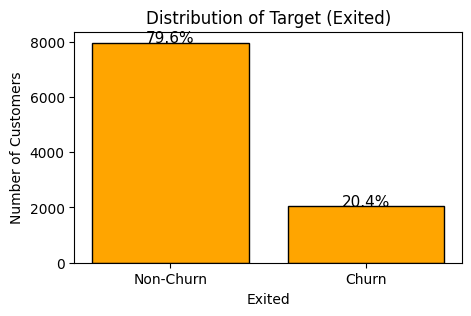

In [354]:
## DISTRIBUTION OF THE TARGET
churn_counts = df["Exited"].value_counts()
churn_pct = df["Exited"].value_counts(normalize=True) * 100

plt.figure(figsize=(5,3))
plt.bar(["Non-Churn", "Churn"], churn_counts.values, color="orange", edgecolor="black")
for i, (value, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    plt.text(i, value + 20, f"{pct:.1f}%", ha="center", fontsize=11)
plt.title("Distribution of Target (Exited)")
plt.ylabel("Number of Customers")
plt.xlabel("Exited")
plt.show()

**KEY INSIGHTS**  
There is a moderate class imbalance. The majority of customers do not churn, while a minority do churn.

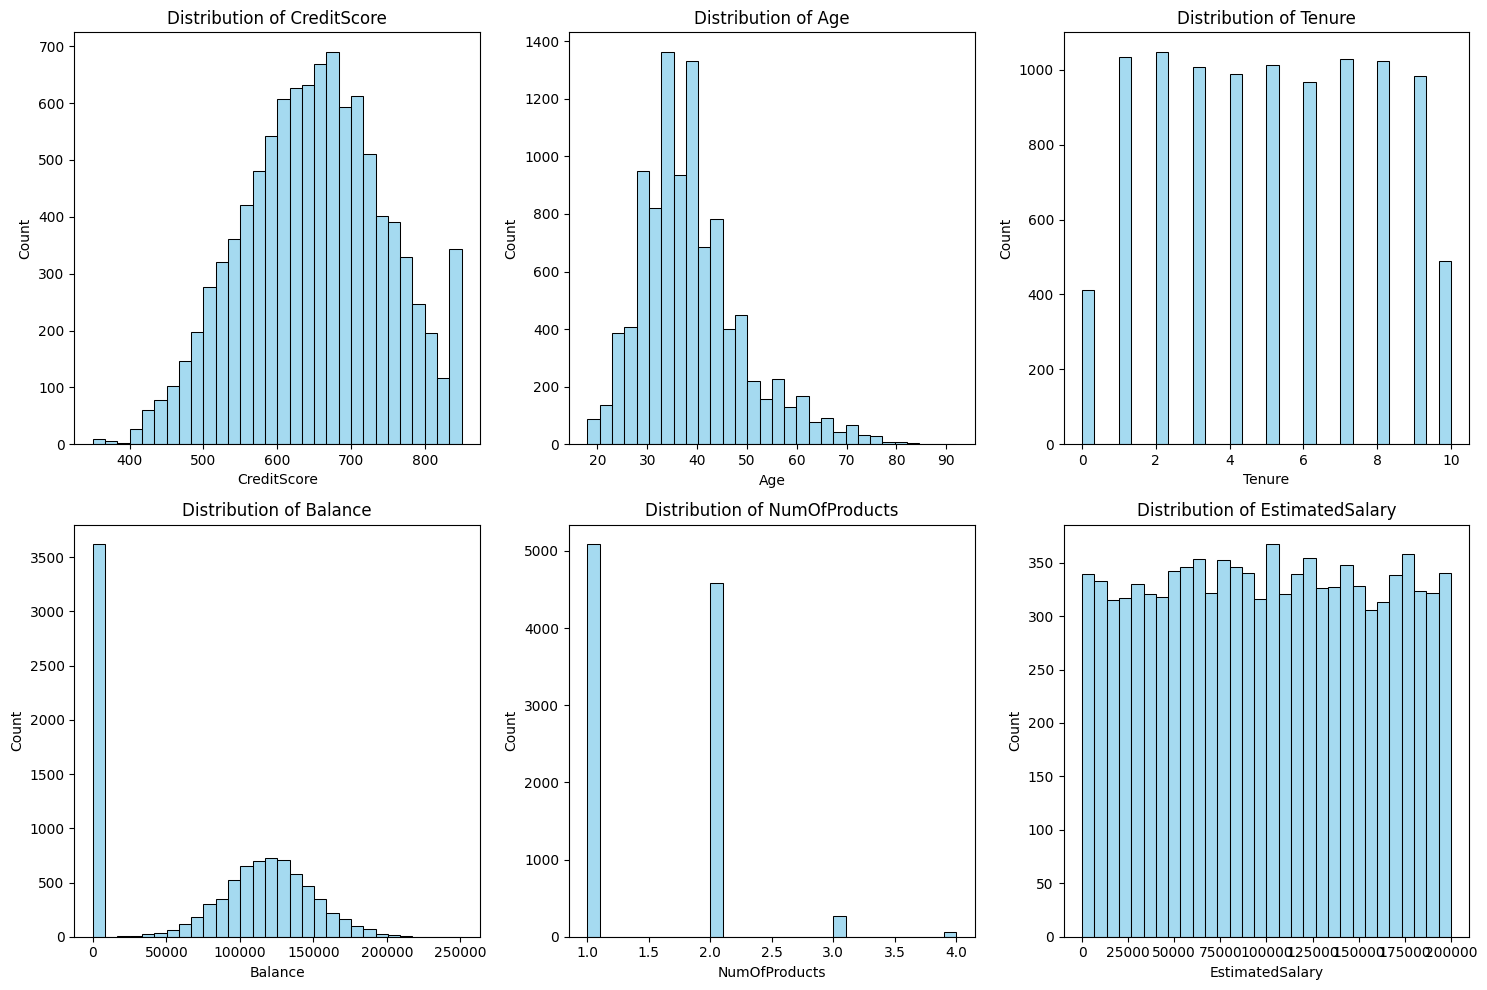

In [355]:
## HISTOGRAMS 
# Visualise the distribution of numeric features

cols_numeric = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary'
       ]

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_numeric):
    plt.subplot(2, 3, i+1) 
    sns.histplot(df[col], bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

**KEY INSIGHTS**
- **CreditScore** : The majority of customers have an average to good credit score, with the majority falling within the 650–700 range. The distribution is relatively symmetrical, suggesting a population with a relatively normal distribution.

- **Age** : The population consists mainly of working-age adults (aged 30–45), with a few older clients creating a right-skewed distribution.

- **Tenure** : Customers are distributed relatively homogeneously according to their tenure, with no significant concentration. The distribution is relatively uniform.

- **Balance** : The balance variable is strongly bimodal, with a large number of customers having a zero balance and another group with a normal distribution centred around 100k–150k. There are two distinct groups: customers without an active account and customers with significant capital.

- **NumOfProducts** : The majority of customers hold between one and two banking products. Customers with more than three products are rare.

- **EstimatedSalary** : The estimated wage is distributed uniformly, suggesting that it does not naturally discriminate against customers.

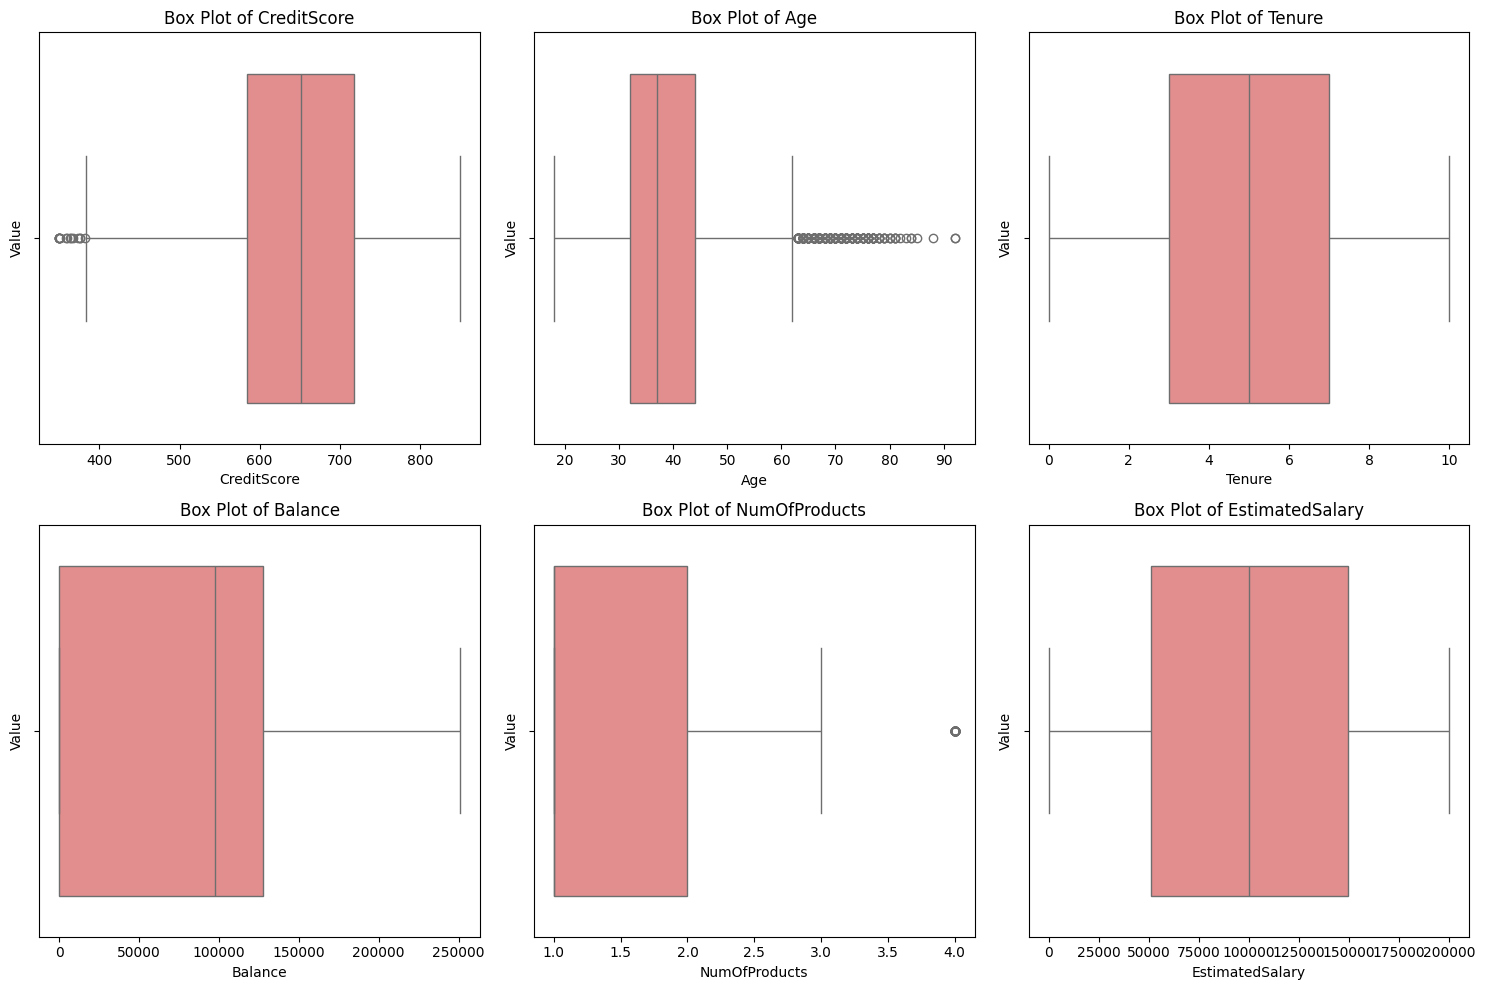

In [356]:
## BOX PLOTS
# Visualise the distribution and outliers of numeric features

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_numeric):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Value')

plt.tight_layout()
plt.show()



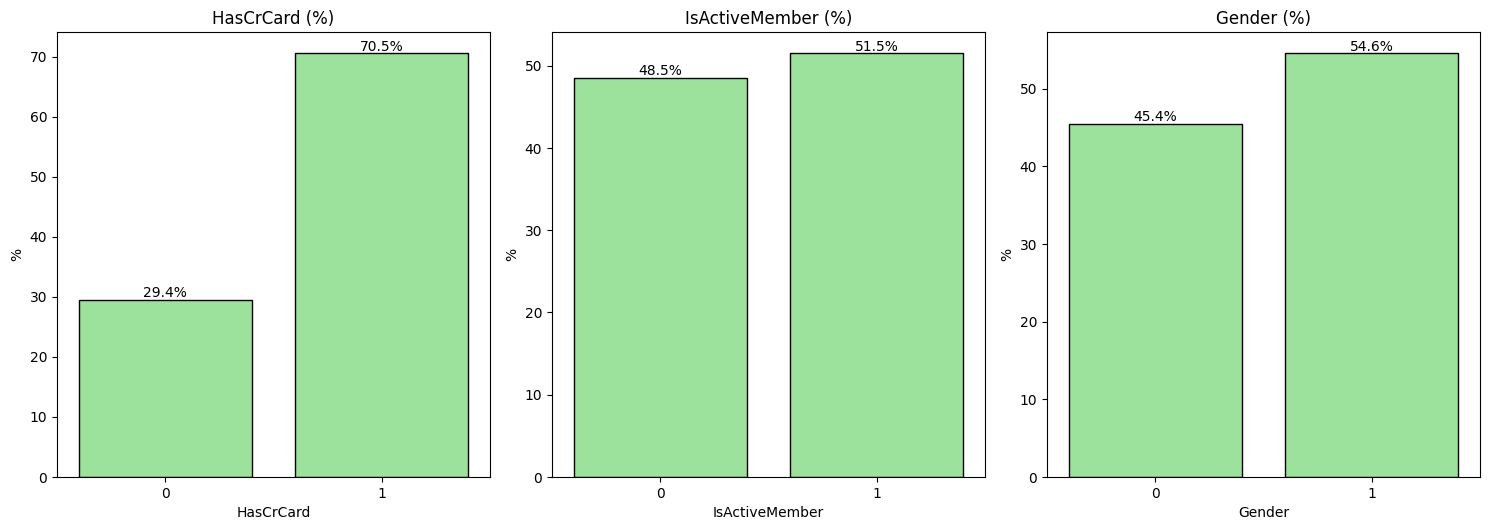

In [357]:
## BAR PLOTS
# Visualise the count of categorical features

cols_categorial = ["HasCrCard", "IsActiveMember", "Gender"]

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_categorial):
    plt.subplot(2, 3, i+1)
    percent = df[col].value_counts(normalize=True).sort_index() * 100
    ax = sns.barplot(x=percent.index, y=percent.values, color='lightgreen', edgecolor='black') 
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom') 
    plt.title(f'{col} (%)')
    plt.ylabel('%')

plt.tight_layout()
plt.show()

**KEY INSIGHTS**  
- **HasCrCard** : The majority of customers have a bank card, while a smaller proportion do not. 

- **IsActiveMember** : Active and inactive members are almost equally represented. Both categories are represented in similar proportions in the dataset.

- **Gender** : The gender distribution is relatively balanced. The gender breakdown is relatively even. There are slightly more men (1) than women (0).

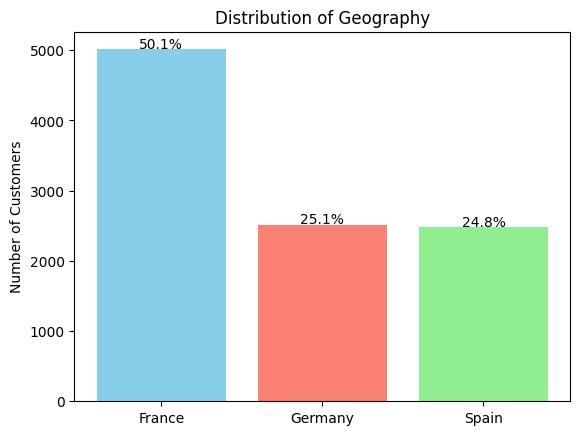

In [358]:
## BAR PLOT FOR DUMMIES

df["Geography"] = "France"
df.loc[df["Geography_Germany"] == 1, "Geography"] = "Germany"
df.loc[df["Geography_Spain"] == 1, "Geography"] = "Spain"

geo_counts = df["Geography"].value_counts()
geo_pct = df["Geography"].value_counts(normalize=True) * 100

plt.bar(geo_counts.index, geo_counts.values, color=["skyblue", "salmon", "lightgreen"])
for i, (value, pct) in enumerate(zip(geo_counts.values, geo_pct.values)):
    plt.text(i, value + 20, f"{pct:.1f}%", ha="center")
plt.title("Distribution of Geography")
plt.ylabel("Number of Customers")

plt.show()

**KEY INSIGHTS**
- **France** accounts for the majority of customers. **Germany** and **Spain** have very similar proportions. The two countries are represented in almost equal numbers.
- The geographical distribution is moderately unbalanced, with France being significantly more represented than the other two countries.

#### 4.2 Bivariate Analysis

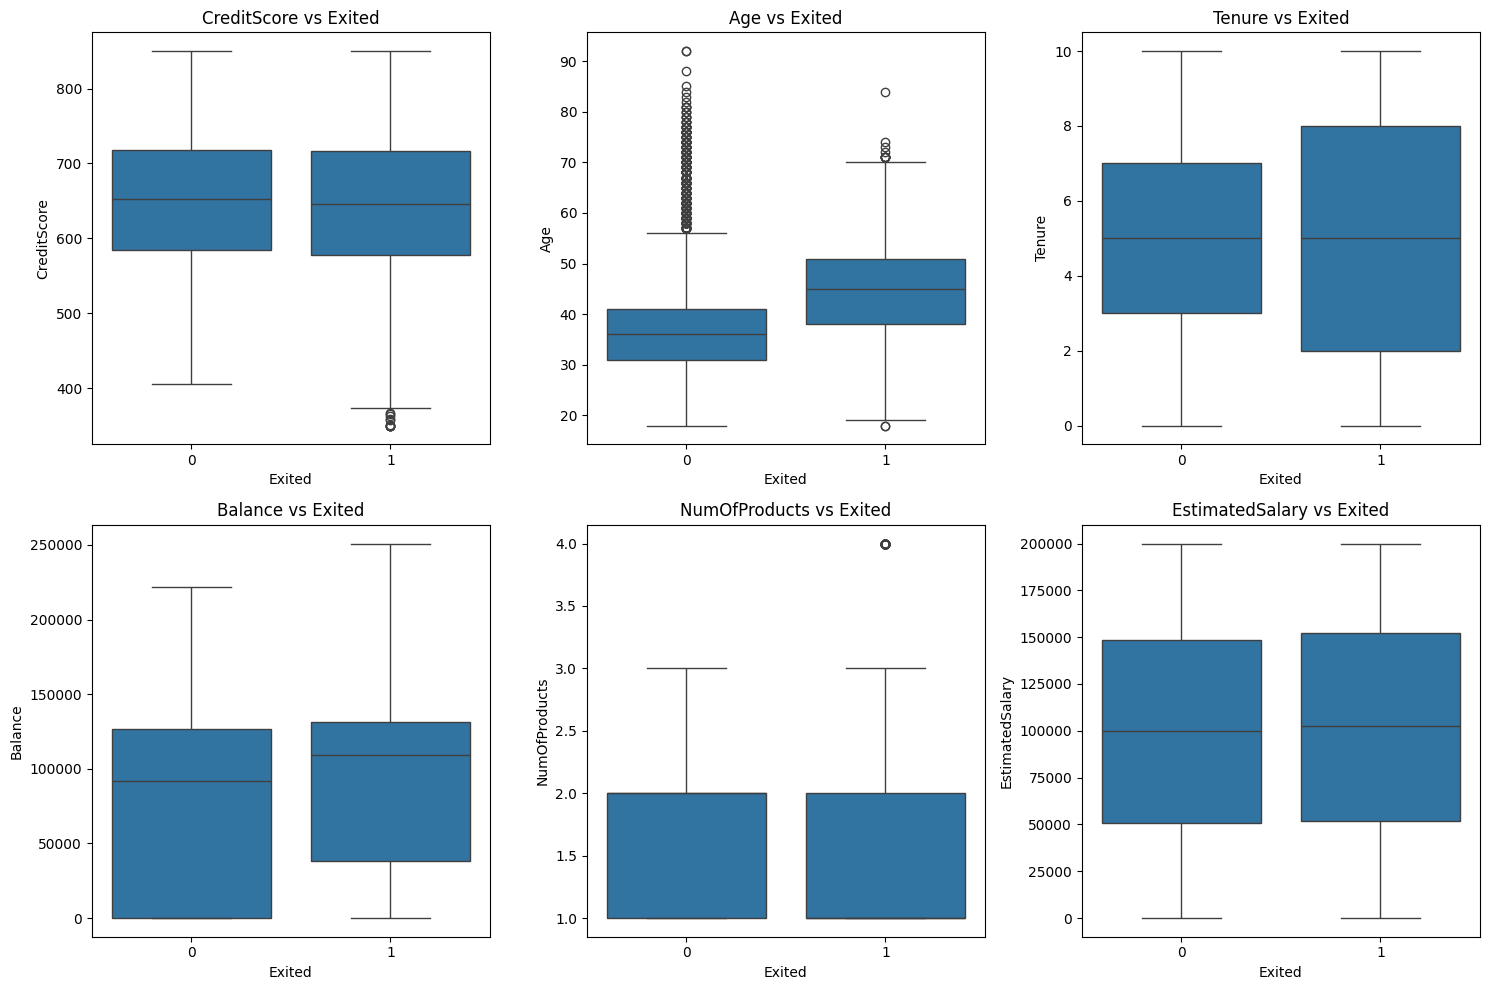

In [359]:
# BOX PLOTS FOR NUMERIC FEATURES VS TARGET

fig, axes = plt.subplots(2, 3, figsize=(15,10))

for ax, col in zip(axes.flatten(), cols_numeric):
    sns.boxplot(x="Exited", y=col, data=df, ax=ax)
    ax.set_title(f"{col} vs Exited")

plt.tight_layout()
plt.show()

**KEY INSIGHTS**
- **CreditScore** : Distributions are relatively similar between the two groups. No major separation is visible between exited and non-exited customers.

- **Age** : The clearest difference between the two groups. Customers who exited tend to be older, with a higher median age compared to customers who stayed.

- **Tenure** : Fairly similar for both groups. The medians and distributions do not show strong differences.

- **Balance** : Surprisingly higher for customers who exited. The median balance of exited customers is above that of non-exited customers.

- **NumofProducts** : Concentrated around 1–2 products for both groups. A few outliers are visible for customers owning more products.

- **EstimatedSalary** : Very similar distributions across the two classes. Salary does not show a strong visible distinction between exited and non-exited customers.

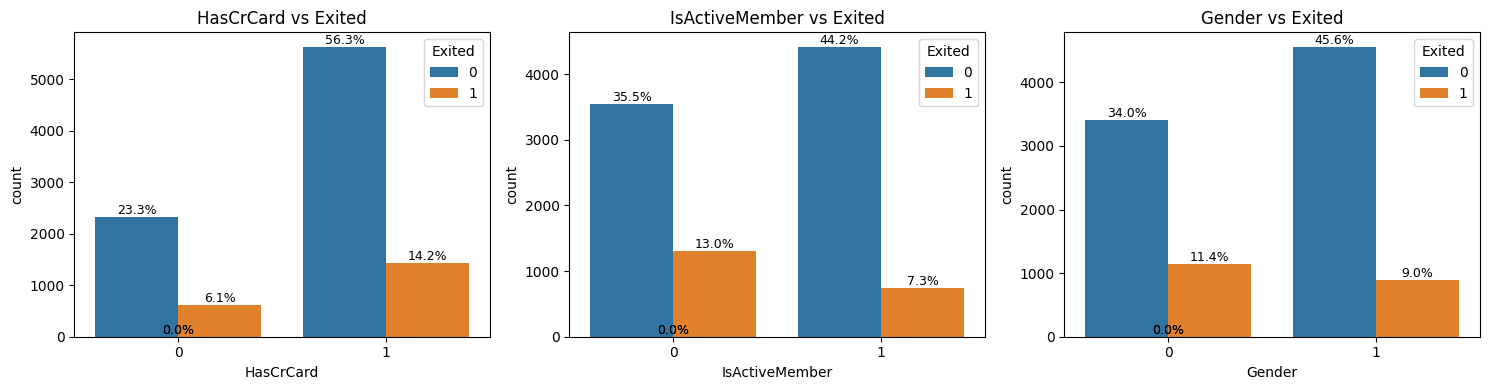

In [360]:
# BAR PLOTS FOR CATEGORICAL FEATURES VS TARGET

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, col in zip(axes, cols_categorial):
    sns.countplot(x=col, hue="Exited", data=df, ax=ax)
    total = len(df)

    for p in ax.patches:
        height = p.get_height()
        pct = 100 * height / total
        ax.annotate(f"{pct:.1f}%",
                    (p.get_x() + p.get_width()/2, height),
                    ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{col} vs Exited")

plt.tight_layout()
plt.show()

**KEY INSIGHTS**
- **HasCrCard** : Most customers have a credit card regardless of exit status. The distribution between exited and non-exited customers remains relatively similar.

- **IsActiveMember** : Non-active members (0) appear more represented among exited customers compared to active members (1). Active customers are more concentrated in the non-exited group.

- **Gender** : Both genders are well represented. Women (0) shows a slightly higher proportion of exited customers compared to Men (1).

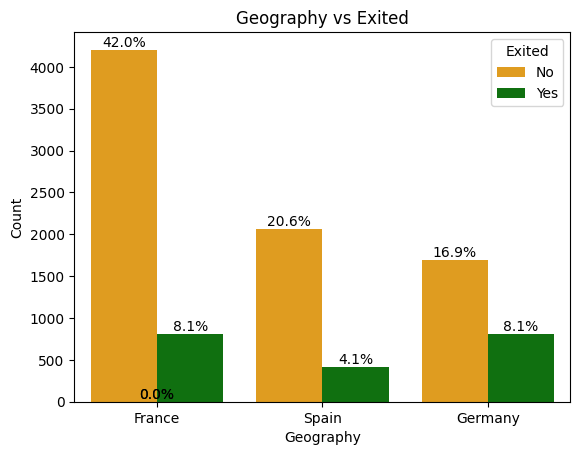

In [361]:
## BAR PLOT GEOGRAPHY VS TARGET 

ax = sns.countplot(x="Geography", hue="Exited", data=df, palette=["orange", "green"])
total = len(df)

for p in ax.patches:
    height = p.get_height()
    pct = 100 * height / total
    ax.annotate(f"{pct:.1f}%",(p.get_x() + p.get_width() / 2, height), ha="center", va="bottom")

plt.title("Geography vs Exited")
plt.xlabel("Geography")
plt.ylabel("Count")
plt.legend(title="Exited", labels=["No", "Yes"])

plt.show()

**KEY INSIGHTS**
- **France** contains the largest number of customers overall and also the largest number of non-exited customers.
- **Germany** shows a noticeably higher proportion of exited customers relative to its total customer count compared to the other countries.
- **Spain** has the lowest number of exited customers among the three countries.

#### 4.3. Heatmap of Correlation Matrix
Heatmap highlights the strength of the correlations, making it easier to spot strong positive or negative relationships between features.

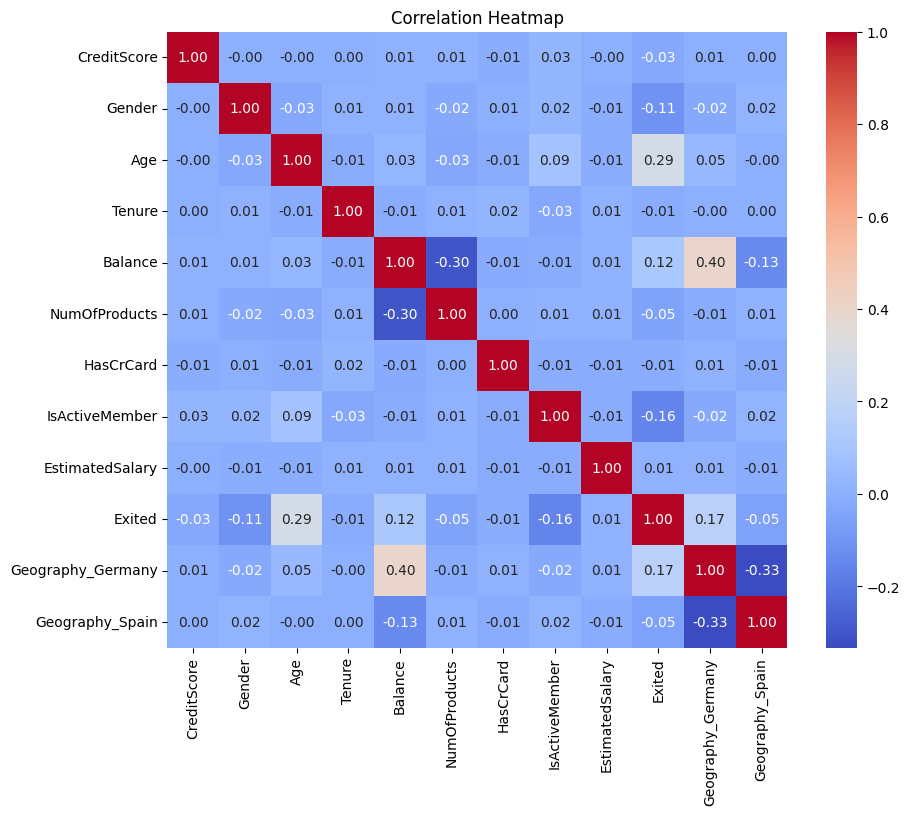

In [362]:
# CORRELATION HEATMAP

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

**KEY INSIGHTS**
- **Age** has the strongest positive correlation with Exited (0.29). Older customers are more associated with exiting compared to younger customers.

- **IsActiveMember** shows the strongest negative correlation with Exited (-0.16). Active members are less associated with customer exit.

- **Geography_Germany** has a moderate positive correlation (0.17). Customers from Germany appear more associated with exiting than customers from other countries.

- **Balance** presents a slight positive correlation with Exited (0.12). Higher account balances are somewhat associated with customer exit.

- **Gender** has a weak negative correlation (-0.11). The relationship exists but remains limited.
- Variables such as **CreditScore**, **Tenure**, **HasCrCard**, **EstimatedSalary**, and **NumOfProducts** show correlations close to zero, indicating weak linear relationships with Exited.

- Overall, correlations with Exited remain relatively low, suggesting that customer churn is influenced by multiple variables together rather than by a single dominant factor.


### **5. Features Engineering**

#### 5.1. Common Features (LR + XGBoost + MLP)

In [363]:
## 1) Balance_Is_Zero
# The distribution of Balance is bimodal: many customers have a balance of 0.
df['Balance_Is_Zero'] = (df['Balance'] == 0).astype(int)

## 2) Balance_Salary_Ratio
# A balance of 100k for someone earning 200k is different from a balance of 100k for someone earning 50k
df['Balance_Salary_Ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)

## 3) IsActive_x_NumProducts
# An inactive customer with multiple products is at high risk of churn.
df['IsActive_x_NumProducts'] = df['IsActiveMember'] * df['NumOfProducts']

## 4) Tenure_Per_Age
# A 5-year term for a 25-year-old customer is very different from a 5-year term for a 60-year-old customer.
df['Tenure_Per_Age'] = df['Tenure'] / (df['Age'] + 1)

####  5.2. Features Specific to Logistic Regression

In [364]:
df_lr = df.copy()

## 5) Age_Squared
# A polynomial term to capture non-linearity. 
# Very young and very old customers behave differently from middle-aged customers.
df_lr['Age_Squared'] = df_lr['Age'] ** 2

## 6) Germany_x_Balance
# Heatmap shows a strong positive correlation between being from Germany and Balance. 
df_lr['Germany_x_Balance'] = df_lr['Geography_Germany'] * df_lr['Balance']


#### Verify Multicolinearity for Logistic Regression

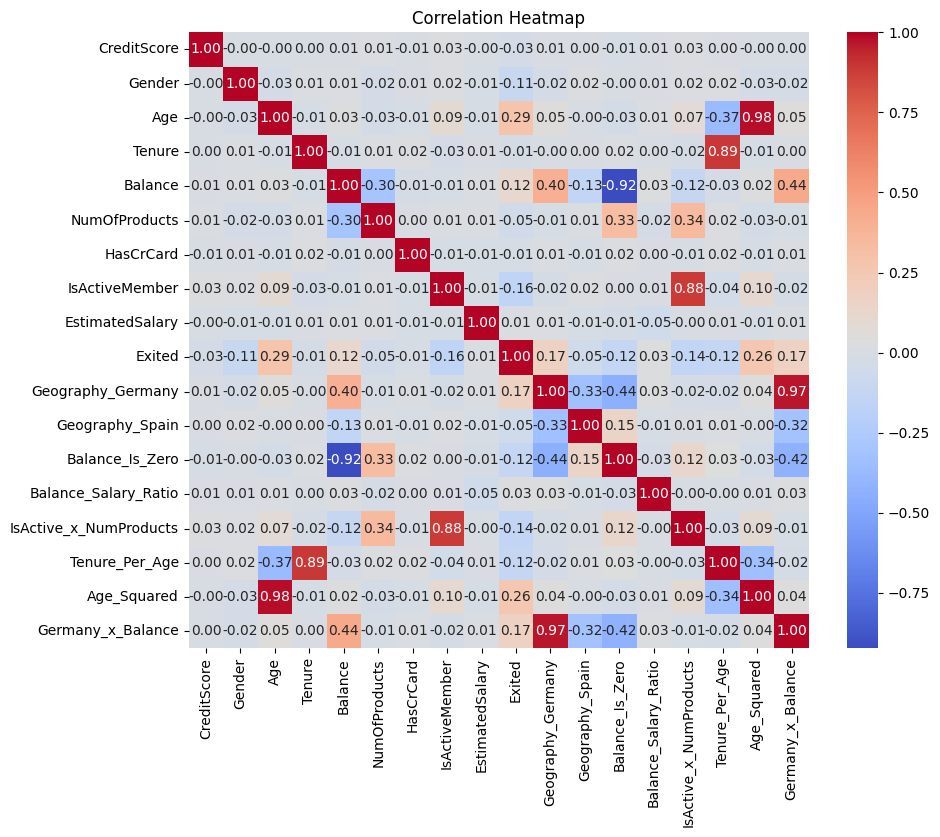

In [365]:
corr = df_lr.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

**FEATURES TO DELETE**  
Multicollinearity is a problem in logistic regression because the model can no longer accurately attribute the impact of each variable on the prediction, making the coefficients unstable and difficult to interpret. 

- **Age**
- **Geography_Germany**
- **IsActiveMember**
- **Tenure**
- **Balance**


In [366]:
df_lr = df_lr.drop(['Age', 'Geography_Germany', 'IsActiveMember', 'Tenure', 'Balance'], axis=1)

### **6. Export DataFrames**

#### 6.1. Export DataSet for XGBoost & MLP

In [367]:
df.to_csv('BankCustomersSet_XGBoost_MLP.csv', index=False)

#### 6.2. Export DataSet for Logistic Regression

In [368]:
df_lr.to_csv('BankCustomersSet_LR.csv', index=False)